# Proyecto BMW

## Data Engineering
Este es el primer entregable que tenéis que realizar. En el campus está el fi chero con los datos, que contiene datos de coches de BMW.
El objetivo es que realicéis la limpieza y el preprocesado de los datos con la fi nalidad de crear un modelo que pueda predecir el precio (¡ojo! no hay que hacer la predicción, pero es el objetivo a tener en cuenta).


In [ ]:
## Os adjunto el formulario en el que están todas las preguntas y que tendréis que rellenar y mandar cuando acabéis:
## htt ps://docs.google.com/forms/d/e/1FAIpQLSfm1X41heoei-hnUWnfBucTPHQbt11txtqFFLljqF0s042kKg/viewform

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd # Librería para la manipulación y el análisis de datos
import numpy as np # Librería para la manipulación de datos y para la ejecución de operaciones matemáticas
import matplotlib.pyplot as plt # Librería para la visualización de datos
import seaborn as sns # Librería para la visualización de datos
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OrdinalEncoder # Librería para crear modelos de ML

In [ ]:
bmw = pd.read_csv("/content/drive/MyDrive/bmw_pricing_v3.csv") # LEEMOS EL FICHERO

In [ ]:
bmw.head() #Hacemos head para ver las 5 primeras columnas empezando por el 0.

,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
0,NaN,118,140411.0,100.0,2012-02-01,diesel,black,NaN,True,True,False,NaN,True,NaN,True,NaN,11300.0,2018-01-01
1,BMW,M4,13929.0,317.0,NaN,petrol,grey,convertible,True,True,False,NaN,False,True,True,True,69700.0,2018-02-01
2,BMW,320,183297.0,120.0,2012-04-01,diesel,white,NaN,False,False,False,NaN,True,False,True,False,10200.0,2018-02-01
3,BMW,420,128035.0,135.0,NaN,diesel,red,convertible,True,True,False,NaN,True,True,True,NaN,25100.0,2018-02-01
4,BMW,425,97097.0,160.0,NaN,diesel,silver,NaN,True,True,False,False,False,True,True,True,33400.0,2018-04-01


In [ ]:
bmw.info()  # Hacemos info, para ver el tipo de dato de cada columna

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   marca                        3873 non-null   object 
 1   modelo                       4840 non-null   object 
 2   km                           4841 non-null   float64
 3   potencia                     4842 non-null   float64
 4   fecha_registro               2420 non-null   object 
 5   tipo_gasolina                4838 non-null   object 
 6   color                        4398 non-null   object 
 7   tipo_coche                   3383 non-null   object 
 8   volante_regulable            4839 non-null   object 
 9   aire_acondicionado           4357 non-null   object 
 10  camara_trasera               4841 non-null   object 
 11  asientos_traseros_plegables  1452 non-null   object 
 12  elevalunas_electrico         4841 non-null   object 
 13  bluetooth         

In [ ]:
bmw["tipo_gasolina"].unique() # Vemos que tantas observaciones tiene la columna Tipo_gasolina

array(['diesel', 'petrol', nan, 'hybrid_petrol', 'Diesel', 'electro'],
      dtype=object)

In [ ]:
bmw.isnull().any() # Miramos en cada columna si tiene nulos o no.

,0
marca,True
modelo,True
km,True
potencia,True
fecha_registro,True
tipo_gasolina,True
color,True
tipo_coche,True
volante_regulable,True
aire_acondicionado,True


In [ ]:
bmw.isnull().sum() # Miramos cuantos nulos tiene cada columna

,0
marca,970
modelo,3
km,2
potencia,1
fecha_registro,2423
tipo_gasolina,5
color,445
tipo_coche,1460
volante_regulable,4
aire_acondicionado,486


In [ ]:
for i in bmw.columns: # Loop en las columnas del DataF
    print('\n',i,bmw[i].unique(),'\n\n') # Print nombre de la columna y valores únicos de ésta


 marca [nan 'BMW'] 



 modelo ['118' 'M4' '320' '420' '425' '335' '325' 'Z4' '120' '220' '650' '135'
 '218' '318' '430' 'M3' '330' '225' 'M235' '316' '435' '640'
 '640 Gran Coupé' '435 Gran Coupé' 'i8' '630' '430 Gran Coupé' '635' '520'
 nan '525' '530' '535' '320 Gran Turismo' '518' '116' '328' '523' 'X3'
 'M550' '528' '325 Gran Turismo' '125' '318 Gran Turismo' '420 Gran Coupé'
 'i3' '114' '520 Gran Turismo' '530 Gran Turismo' 'M135' '418 Gran Coupé'
 '330 Gran Turismo' '335 Gran Turismo' '730' '123' '535 Gran Turismo'
 '740' '750' 'ActiveHybrid 5' '735' 'M5' 'X5' 'X1' 'X4' 'X6' 'X6 M' 'X5 M'
 'X5 M50' '218 Active Tourer' '218 Gran Tourer' '216' '220 Active Tourer'
 '216 Gran Tourer' '216 Active Tourer' ' Active Tourer'
 '225 Active Tourer' '214 Gran Tourer'] 



 km [140411.  13929. 183297. ...  19633.  27920. 195840.] 



 potencia [100. 317. 120. 135. 160. 225. 145. 105. 125. 130. 270. 110. 140. 180.
  85. 190. 236. 240. 250. 230. 309. 170. 142. 155. 210.  nan 122. 200.
  90. 15

<Axes: >

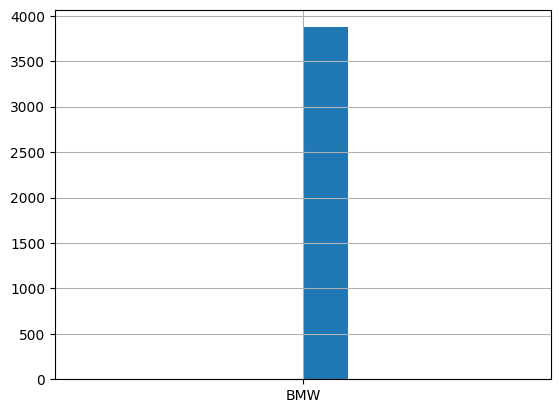

In [ ]:
bmw["marca"].hist() # Hacemos un Hist de marca para ver valores unicos agrupados,
# vemos que no existe otra marca. todo el documento es de la marca BMW por lo que es una columnaque no aporta valor al modelo


##DUPLICADOS

In [ ]:
bmw[bmw.duplicated(keep=False)] ## miramos cuantos duplicados tenemos. No se aprecian observaciones duplicadas.

,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta


# Ejercicio 1.

### ¿Qué columnas eliminaron inicialmente del dataset y por qué?

In [ ]:
# ELIMINAR COLUMNAS: Marca + Asientos_traseros_plegables
# Marca: Es eliminado porque todo el DataSet pertenecen a la marca de BMW,
# Asientos_traseros_plegables: El 75% de las observaciones son valores nulos y no son suficientes para el modelo,
# Nos quedamos con 16 columnas.

In [ ]:
bmw1 = bmw.copy()   # hacemos copia del DataF original.

In [ ]:
del(bmw1["marca"]) # Eliminamos Marca.

In [ ]:
del(bmw1["asientos_traseros_plegables"]) # Eliminamos asientos_traseros_plegables.

In [ ]:
bmw.shape

(4843, 18)

In [ ]:
bmw1.shape

(4843, 16)

In [ ]:
bmw1["modelo"].value_counts() # Vemos la proporcion de modelos.

,count
modelo,
320,752
520,633
318,568
X3,438
116,358
...,...
216,1
220 Active Tourer,1
Active Tourer,1


In [ ]:
bmw1.isnull().sum() # Miramos cuantos nulos tiene cada columna

,0
modelo,0
km,2
potencia,1
fecha_registro,2423
tipo_gasolina,5
color,445
tipo_coche,1460
volante_regulable,4
aire_acondicionado,486
camara_trasera,2


In [ ]:
bmw1[bmw1["modelo"].isnull()] # Miramos para la columna de Modelo, todos los registros en null. son tres registros.

,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
173,NaN,146338.0,105.0,NaN,diesel,black,NaN,False,True,False,False,NaN,True,NaN,13300.0,2018-08-01
4766,NaN,115566.0,105.0,2014-01-01,diesel,silver,suv,False,True,False,True,False,True,False,14900.0,2018-09-01
4802,NaN,118640.0,110.0,NaN,diesel,white,NaN,False,False,False,False,False,False,False,800.0,2018-03-01


In [ ]:
# ✅ CORRECTO - Obtener el primer valor de la Series mode
moda = bmw1['modelo'].mode()[0]  # [0] para obtener el valor, no la Series
bmw1['modelo'].fillna(moda, inplace=True) # Substituimos las columnas en null por la moda y no la mediana. ( sumamos los nulos a la moda )

/tmp/ipython-input-3958415762.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bmw1['modelo'].fillna(moda, inplace=True) # Substituimos las columnas en null por la moda y no la mediana. ( sumamos los nulos a la moda )


In [ ]:
bmw1[bmw1["modelo"].isnull()] # Miramos para la columna de Modelo, todos los registros en null. Ya no tenemos porque han sido substituidos por la moda.

,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta


In [ ]:
print((bmw1.isnull().sum() / len(bmw1)) * 100) # Miramos la canitdad % nulos en cada columna.

modelo                   0.000000
km                       0.041297
potencia                 0.020648
fecha_registro          50.030973
tipo_gasolina            0.103242
color                    9.188520
tipo_coche              30.146603
volante_regulable        0.082593
aire_acondicionado      10.035102
camara_trasera           0.041297
elevalunas_electrico     0.041297
bluetooth               15.032005
gps                      0.000000
alerta_lim_velocidad    15.032005
precio                   0.123890
fecha_venta              0.020648
dtype: float64


In [ ]:
bmw2=bmw1.copy()

In [ ]:
bmw2.describe()

,km,potencia,precio
count,4.841000e+03,4842.000000,4837.000000
mean,1.409593e+05,128.981826,15831.920612
std,6.020853e+04,38.994839,9222.630708
min,-6.400000e+01,0.000000,100.000000
25%,1.028840e+05,100.000000,10800.000000
50%,1.410800e+05,120.000000,14200.000000
75%,1.752170e+05,135.000000,18600.000000
max,1.000376e+06,423.000000,178500.000000


In [ ]:
bmw2.describe(exclude=['object', 'bool'])

,km,potencia,precio
count,4.841000e+03,4842.000000,4837.000000
mean,1.409593e+05,128.981826,15831.920612
std,6.020853e+04,38.994839,9222.630708
min,-6.400000e+01,0.000000,100.000000
25%,1.028840e+05,100.000000,10800.000000
50%,1.410800e+05,120.000000,14200.000000
75%,1.752170e+05,135.000000,18600.000000
max,1.000376e+06,423.000000,178500.000000


Al hacer describe para las variables numéricas, surgen varios problemas:
* el mínimo de km es -64. Valor negativo no puede ser! El máx es kms es de 1.000.000 de kms. Es demasiado alto!
* La potencia mínima es 0, ¿Coche con 0 de potencia? Mientras que el máximo es de 423 (posible outlier)
* El máximo de precio es de 178.500. Es demasiado alto!

In [ ]:
# Para ver valores más bajos - COLOCA UNA COLUMNA A LA VEZ
print("VALORES MÁS BAJOS DE KM:")
print(bmw2['km'].nsmallest(5))

print("\nVALORES MÁS BAJOS DE POTENCIA:")
print(bmw2['potencia'].nsmallest(5))

print("\nVALORES MÁS BAJOS DE PRECIO:")
print(bmw2['precio'].nsmallest(5))

print("\nVALORES MÁS ALTOS DE KM:")
print(bmw2['km'].nlargest(5))

print("\nVALORES MÁS ALTOS DE POTENCIA:")
print(bmw2['potencia'].nlargest(5))

print("\nVALORES MÁS ALTOS DE PRECIO:")
print(bmw2['precio'].nlargest(5))

VALORES MÁS BAJOS DE KM:
2938     -64.0
2409     476.0
4372     612.0
3935     706.0
3687    2399.0
Name: km, dtype: float64

VALORES MÁS BAJOS DE POTENCIA:
3765     0.0
1796    25.0
1925    25.0
2390    66.0
2771    66.0
Name: potencia, dtype: float64

VALORES MÁS BAJOS DE PRECIO:
565     100.0
630     100.0
879     100.0
1255    100.0
1832    100.0
Name: precio, dtype: float64

VALORES MÁS ALTOS DE KM:
3732    1000376.0
557      484615.0
2350     477571.0
2829     439060.0
3198     405816.0
Name: km, dtype: float64

VALORES MÁS ALTOS DE POTENCIA:
4146    423.0
3601    412.0
1       317.0
72      317.0
2944    317.0
Name: potencia, dtype: float64

VALORES MÁS ALTOS DE PRECIO:
4753    178500.0
4684    142800.0
90       95200.0
4146     82400.0
2938     75000.0
Name: precio, dtype: float64


In [ ]:
# Versión menos estricta
bmw2_suave = bmw2.copy()

# Solo eliminar lo OBVIAMENTE incorrecto
bmw2_suave = bmw2_suave[
    (bmw2_suave['km'] >= 0) &           # Eliminar km negativos
    (bmw2_suave['km'] <= 500000) &      # KM máximo más alto
    (bmw2_suave['potencia'] > 0) &      # Eliminar potencia 0
    (bmw2_suave['potencia'] <= 450) &   # Potencia máxima más alta
    (bmw2_suave['precio'] >= 1000) &    # Precio mínimo bajo
    (bmw2_suave['precio'] <= 150000)    # Precio máximo alto
]

print(f"Versión suave: {len(bmw2_suave)} coches válidos")

Versión suave: 4769 coches válidos


In [ ]:
#Convertimos las fechas a formato datetime.
for i in ["fecha_registro","fecha_venta"]:
    bmw2[i] = pd.to_datetime(bmw2[i])

In [ ]:
bmw2_suave.info() # En el info podemos ver que; fecha_registro y fecha_venta, tienen ahora un formato Datatime ns64.

<class 'pandas.core.frame.DataFrame'>
Index: 4769 entries, 0 to 4842
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   modelo                4769 non-null   object 
 1   km                    4769 non-null   float64
 2   potencia              4769 non-null   float64
 3   fecha_registro        2382 non-null   object 
 4   tipo_gasolina         4765 non-null   object 
 5   color                 4333 non-null   object 
 6   tipo_coche            3331 non-null   object 
 7   volante_regulable     4765 non-null   object 
 8   aire_acondicionado    4293 non-null   object 
 9   camara_trasera        4767 non-null   object 
 10  elevalunas_electrico  4767 non-null   object 
 11  bluetooth             4050 non-null   object 
 12  gps                   4769 non-null   bool   
 13  alerta_lim_velocidad  4048 non-null   object 
 14  precio                4769 non-null   float64
 15  fecha_venta           4768

In [ ]:
# 1. PRIMERO convertir las columnas a datetime
bmw2_suave["fecha_registro"] = pd.to_datetime(bmw2_suave["fecha_registro"], errors='coerce')
bmw2_suave["fecha_venta"] = pd.to_datetime(bmw2_suave["fecha_venta"], errors='coerce')

# 2. AHORA calcular la diferencia
bmw2_suave["DIF_TIEMPO"] = bmw2_suave["fecha_venta"] - bmw2_suave["fecha_registro"]

# 3. Verificar resultado
print(bmw2_suave["DIF_TIEMPO"].head())

0   2161 days
1         NaT
2   2132 days
3         NaT
4         NaT
Name: DIF_TIEMPO, dtype: timedelta64[ns]


In [ ]:
bmw2_suave # observamos que ya tenemos la columna agregada al DataF.

,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta,DIF_TIEMPO
0,118,140411.0,100.0,2012-02-01,diesel,black,NaN,True,True,False,True,NaN,True,NaN,11300.0,2018-01-01,2161 days
1,M4,13929.0,317.0,NaT,petrol,grey,convertible,True,True,False,False,True,True,True,69700.0,2018-02-01,NaT
2,320,183297.0,120.0,2012-04-01,diesel,white,NaN,False,False,False,True,False,True,False,10200.0,2018-02-01,2132 days
3,420,128035.0,135.0,NaT,diesel,red,convertible,True,True,False,True,True,True,NaN,25100.0,2018-02-01,NaT
4,425,97097.0,160.0,NaT,diesel,silver,NaN,True,True,False,False,True,True,True,33400.0,2018-04-01,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4838,218 Gran Tourer,39743.0,110.0,NaT,diesel,black,NaN,False,True,False,False,False,True,False,14600.0,2018-08-01,NaT
4839,218 Active Tourer,49832.0,100.0,2015-06-01,diesel,grey,NaN,False,True,False,False,False,True,True,17500.0,2018-08-01,1157 days
4840,218 Gran Tourer,19633.0,110.0,2015-10-01,diesel,grey,van,False,True,False,False,False,True,True,17000.0,2018-09-01,1066 days
4841,218 Active Tourer,27920.0,110.0,2016-04-01,diesel,brown,van,True,True,False,False,False,True,True,22700.0,2018-09-01,883 days


In [ ]:
bmw2_suave = bmw2_suave.drop(['fecha_registro', 'fecha_venta'], axis=1)

In [ ]:
#Tipo_Gasolina, Remplazar "diesel" y "Diesel"
# Preguntar el Miercoles en clase: FechaRegistro: 2423, 50% nulos, Porcentaje minimo para passar a media o mediana.

# Punto1
# Marca, se elimina porque solo hai un tipo de observacion y nulos. por lo que es una columna que no aporta nada al modelo
#Asientos_Traseros_plegables, Falta de observacines, 3391 nulos. no aporta valor al modelo.

# El DataSet: NO tiene duplicados:  bmw[bmw.duplicated(keep=False)]

#Punto 3, hacer Histograma Scatter Plot, Violin Plot, Graphics.

#En las variables numericas, haremos describe.

#Al final hacer una correlacion de variables con el precio, para ver la fiabilidad del modelo.

#Análisis univarible
#- Describe() -- análisis de outliers, extremos ,
#- Hist() -- de cada uno de ellos con plt y un for columna in lista_variable_numericas

In [ ]:
bmw2_suave.groupby (['modelo']).agg ({'precio': 'describe'}).sort_values(by=('precio','mean'))

precio                                                                  \
        count          mean           std      min      25%      50%      75%   
modelo                                                                          
735       1.0   4500.000000           NaN   4500.0   4500.0   4500.0   4500.0   
216       1.0   4800.000000           NaN   4800.0   4800.0   4800.0   4800.0   
650       2.0   8000.000000   1697.056275   6800.0   7400.0   8000.0   8600.0   
123       2.0   8800.000000   3676.955262   6200.0   7500.0   8800.0  10100.0   
Z4        6.0   9500.000000   5675.561646   6200.0   6350.0   7100.0   9050.0   
...       ...           ...           ...      ...      ...      ...      ...   
M5        1.0  41600.000000           NaN  41600.0  41600.0  41600.0  41600.0   
X5 M50    3.0  49533.333333    635.085296  48800.0  49350.0  49900.0  49900.0   
X6 M      8.0  51050.000000  16116.096656  34800.0  39300.0  45800.0  58900.0   
M4        2.0  61650.000000  11384.419177  53600.0  57625.0  61650.0  65675.0   
i8        1.0  95200.000000           NaN  95200.0  95200.0  95200.0  95200.0   

                 
            max  
modelo           
735      4500.0  
216      4800.0  
650      9200.0  
123     11400.0  
Z4      20800.0  
...         ...  
M5      41600.0  
X5 M50  49900.0  
X6 M    82400.0  
M4      69700.0  
i8      95200.0  

[76 rows x 8 columns]

In [ ]:
# Porcentaje de cada color dentro de cada modelo
porcentaje_colores = (bmw2_suave.groupby(['modelo', 'color']).size() /
                      bmw2_suave.groupby('modelo').size() * 100).unstack(fill_value=0)
porcentaje_colores.round(2)

color,beige,black,blue,brown,green,grey,orange,red,silver,white
modelo,,,,,,,,,,
Active Tourer,0.0,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
114,0.0,33.33,6.67,13.33,0.00,13.33,0.00,0.00,6.67,13.33
116,0.0,33.05,19.33,4.48,0.00,18.49,0.28,0.84,4.20,11.48
118,0.0,30.50,18.44,0.71,0.71,26.95,0.00,0.71,2.84,8.51
120,0.0,19.44,22.22,0.00,0.00,13.89,0.00,0.00,11.11,16.67
...,...,...,...,...,...,...,...,...,...,...
X6,0.0,50.00,2.27,0.00,2.27,15.91,0.00,0.00,4.55,15.91
X6 M,0.0,25.00,12.50,0.00,0.00,12.50,0.00,12.50,0.00,12.50
Z4,0.0,66.67,0.00,0.00,0.00,16.67,16.67,0.00,0.00,0.00


In [ ]:
# Esta forma siempre funciona
bmw2_suave['color'] = bmw2_suave.groupby('modelo')['color'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Desconocido')
)

print(f"Listo. Nulls: {bmw2_suave['color'].isnull().sum()}")

Listo. Nulls: 0


In [ ]:
#Desnormalizar.
np.exp(13-1)

np.float64(162754.79141900392)

In [ ]:
#TRANSFORM

In [ ]:
bmw2_suave["tipo_gasolina"].fillna(bmw2_suave["tipo_gasolina"].mode()[0], inplace=True)

/tmp/ipython-input-3618533104.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bmw2_suave["tipo_gasolina"].fillna(bmw2_suave["tipo_gasolina"].mode()[0], inplace=True)


In [ ]:
bmw2_suave["volante_regulable"].fillna(bmw2_suave["volante_regulable"].mode()[0], inplace=True)

/tmp/ipython-input-3531365395.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bmw2_suave["volante_regulable"].fillna(bmw2_suave["volante_regulable"].mode()[0], inplace=True)
/tmp/ipython-input-3531365395.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bmw2_suave["volante_regulable"].fillna(bmw2_suave["v

In [ ]:
bmw2_suave.isnull().sum()

,0
modelo,0
km,0
potencia,0
tipo_gasolina,0
color,0
tipo_coche,1438
volante_regulable,0
aire_acondicionado,476
camara_trasera,2
elevalunas_electrico,2


In [ ]:
bmw2_suave["camara_trasera"].fillna(bmw2_suave["camara_trasera"].mode()[0], inplace=True)

/tmp/ipython-input-448563137.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bmw2_suave["camara_trasera"].fillna(bmw2_suave["camara_trasera"].mode()[0], inplace=True)
/tmp/ipython-input-448563137.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bmw2_suave["camara_trasera"].fillna(bmw2_suave["camara_trase

In [ ]:
bmw2_suave["elevalunas_electrico"].fillna(bmw2_suave["elevalunas_electrico"].mode()[0], inplace=True)

/tmp/ipython-input-2242920480.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bmw2_suave["elevalunas_electrico"].fillna(bmw2_suave["elevalunas_electrico"].mode()[0], inplace=True)
/tmp/ipython-input-2242920480.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bmw2_suave["elevalunas_electrico"].fillna(bmw2

In [ ]:
bmw2_suave['km'] = pd.to_numeric(bmw2_suave['km'], errors='coerce')

In [ ]:
#Sin ejecutar esta función, al quitar outliers, también se me han limpiado los valores de kms nulls.


media_km = bmw2['km'].mean()
bmw2['km'].fillna(media_km, inplace=True)


/tmp/ipython-input-1929565950.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bmw2['km'].fillna(media_km, inplace=True)


In [ ]:
bmw2_suave['potencia'] = pd.to_numeric(bmw2_suave['potencia'], errors='coerce')

In [ ]:
#Sin ejecutar esta función, al quitar outliers, también se me han limpiado los valores de kms nulls.


media_km = bmw2['potencia'].mean()
bmw2['potencia'].fillna(media_km, inplace=True)


/tmp/ipython-input-2964651175.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bmw2['potencia'].fillna(media_km, inplace=True)


In [ ]:
df['Postal_code.Mean_price']=df.groupby(['Postal Code'])['Price'].transform('mean')

NameError: name 'df' is not defined

In [ ]:
df['Price']=np.where(
    df['Price'].isna(),
    df['Postal Code Mean Price'],
    df['Price']
)

NameError: name 'df' is not defined

In [ ]:
bmw2_suave.isnull().sum()

,0
modelo,0
km,0
potencia,0
tipo_gasolina,0
color,0
tipo_coche,1438
volante_regulable,0
aire_acondicionado,476
camara_trasera,0
elevalunas_electrico,0


<Axes: >

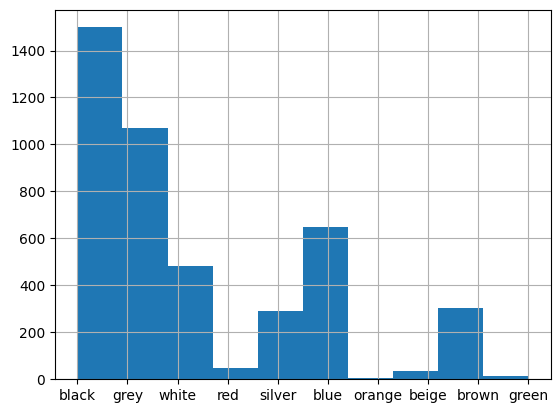

In [ ]:
bmw["color"].hist()

In [ ]:
bmw2_suave["alerta_lim_velocidad"].value_counts()

,count
alerta_lim_velocidad,
True,2210
False,1838


In [ ]:
bmw2_suave["tipo_coche"].value_counts()

,count
tipo_coche,
estate,1082
sedan,807
suv,746
hatchback,486
subcompact,77
coupe,75
convertible,30
van,28


In [ ]:
# Para tipo_coche, como no hay una distribución clara, rellenamos los nulls con el valor "Desconocido"

bmw2_suave['tipo_coche'] = bmw2_suave['tipo_coche'].fillna('Desconocido')

In [ ]:
bmw2_suave.value_counts()

modelo  km       potencia  tipo_gasolina  color  tipo_coche   volante_regulable  aire_acondicionado  camara_trasera  elevalunas_electrico  bluetooth  gps    alerta_lim_velocidad  precio   DIF_TIEMPO
Z4      82761.0  110.0     petrol         grey   convertible  True               False               False           False                 True       True   False                 9500.0   4748 days     1
114     17013.0  75.0      petrol         black  hatchback    False              False               False           False                 False      True   False                 10700.0  1247 days     1
        25703.0  70.0      diesel         grey   subcompact   False              True                False           False                 False      True   False                 8200.0   851 days      1
        51376.0  75.0      petrol         black  hatchback    False              False               False           True                  True       True   False                 14300.0  2038 days     1
        52198.0  75.0      petrol         black  Desconocido  False              False               False           True                  True       True   False                 14300.0  1977 days     1
                                                                                                                                                                                                         ..
116     42851.0  85.0      diesel         black  subcompact   False              False               False           False                 False      True   False                 16700.0  1127 days     1
        42500.0  85.0      diesel         black  hatchback    False              True                False           False                 False      True   False                 13700.0  882 days      1
        38917.0  85.0      diesel         white  hatchback    False              True                False           False                 False      False  False                 7100.0   1277 days     1
        38596.0  85.0      diesel         black  hatchback    False              False               False           False                 False      True   False                 10900.0  1918 days     1
        27531.0  85.0      diesel         black  Desconocido  False              True                False           True                  True       True   False                 2800.0   1155 days     1
Name: count, Length: 1535, dtype: int64

In [ ]:
bmw2_suave["aire_acondicionado"].value_counts()

,count
aire_acondicionado,
True,3443
False,850


In [ ]:
# Porcentaje de coches CON aire acondicionado por modelo
porcentaje_aire = bmw2_suave.groupby('modelo')['aire_acondicionado'].mean() * 100
print("Porcentaje con aire acondicionado por modelo:")
print(porcentaje_aire.sort_values(ascending=False))

Porcentaje con aire acondicionado por modelo:
modelo
 Active Tourer   -100.0
114              -100.0
116              -100.0
118              -100.0
120              -100.0
                  ...  
X6               -100.0
X6 M             -100.0
Z4               -100.0
i3               -100.0
i8               -100.0
Name: aire_acondicionado, Length: 76, dtype: float64


In [ ]:
# Código fácil para transformar aire_acondicionado

# 1. Primero mira qué valores tienes
print("Valores que hay ahora:")
print(bmw2_suave['aire_acondicionado'].unique())

# 2. Transforma todo
bmw2_suave['aire_acondicionado'] = bmw2_suave['aire_acondicionado'].map({
    True: 1,
    False: 0
})

# 3. Cambia los que están vacíos por -1
bmw2_suave['aire_acondicionado'] = bmw2_suave['aire_acondicionado'].fillna(-1)

# 5. Verifica que quedó bien
print("\nDespués del cambio:")
print(bmw2_suave['aire_acondicionado'].value_counts())
print("\n1 = True, 0 = False, -1 = Desconocido")

Valores que hay ahora:
[-1.]

Después del cambio:
aire_acondicionado
-1.0    4769
Name: count, dtype: int64

1 = True, 0 = False, -1 = Desconocido


In [ ]:
# Porcentaje de coches CON Bluetooth por modelo
porcentaje_bluetooth = bmw2_suave.groupby('modelo')['bluetooth'].mean() * 100
print("Porcentaje con bluetooth por modelo:")
print(porcentaje_bluetooth.sort_values(ascending=False))

Porcentaje con bluetooth por modelo:
modelo
M235                100.0
M550                100.0
430                 100.0
335 Gran Turismo    100.0
335                 100.0
                    ...  
735                   0.0
650                   0.0
635                   0.0
i8                    0.0
 Active Tourer        NaN
Name: bluetooth, Length: 76, dtype: object


/tmp/ipython-input-3669883131.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='modelo', y='bluetooth', data=bmw2, inner='stick', palette='Set2')


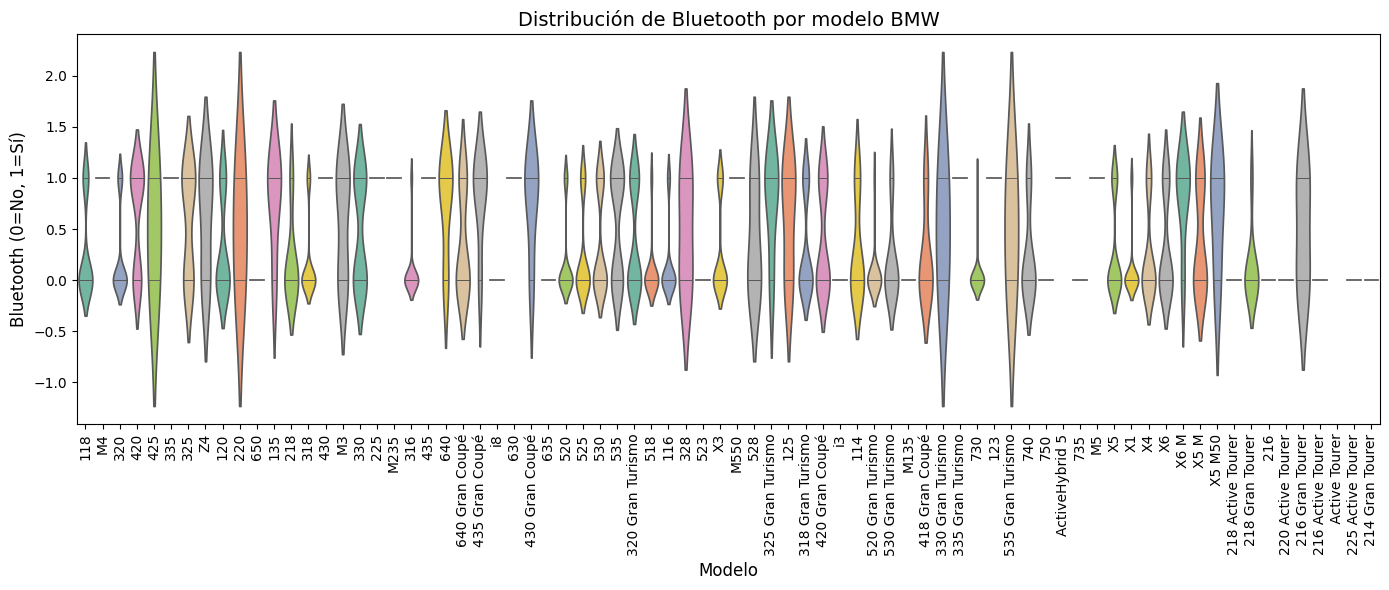

In [ ]:
plt.figure(figsize=(14, 6))
sns.violinplot(x='modelo', y='bluetooth', data=bmw2, inner='stick', palette='Set2')

# Mejorar visualización
plt.title('Distribución de Bluetooth por modelo BMW', fontsize=14)
plt.xlabel('Modelo', fontsize=12)
plt.ylabel('Bluetooth (0=No, 1=Sí)', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Rellenar NaN con el valor más frecuente de cada modelo
bmw2_suave['bluetooth'] = bmw2_suave.groupby('modelo')['bluetooth'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else False)
)

/tmp/ipython-input-2017658225.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  lambda x: x.fillna(x.mode()[0] if not x.mode().empty else False)


In [ ]:
bmw2_suave["bluetooth"].value_counts()

,count
bluetooth,
False,3748
True,1021


In [ ]:
bmw2_suave["alerta_lim_velocidad"].value_counts(dropna=False)

,count
alerta_lim_velocidad,
True,2210
False,1838
NaN,721


In [ ]:
bmw2_suave.groupby('alerta_lim_velocidad', dropna=False).agg({'precio': 'describe'})

precio                                              \
                       count          mean          std     min      25%   
alerta_lim_velocidad                                                       
NaN                    721.0  15781.137309  8367.973293  1100.0  10800.0   
False                 1838.0  11568.661589  4563.207270  1000.0   9200.0   
True                  2210.0  19716.380090  9787.435406  1300.0  14000.0   

                                                  
                          50%      75%       max  
alerta_lim_velocidad                              
NaN                   13800.0  18600.0   65400.0  
False                 11400.0  14000.0   64300.0  
True                  17400.0  22600.0  142800.0

/tmp/ipython-input-1352040186.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='modelo', y='alerta_lim_velocidad', data=bmw2, inner='stick', palette='Set2')


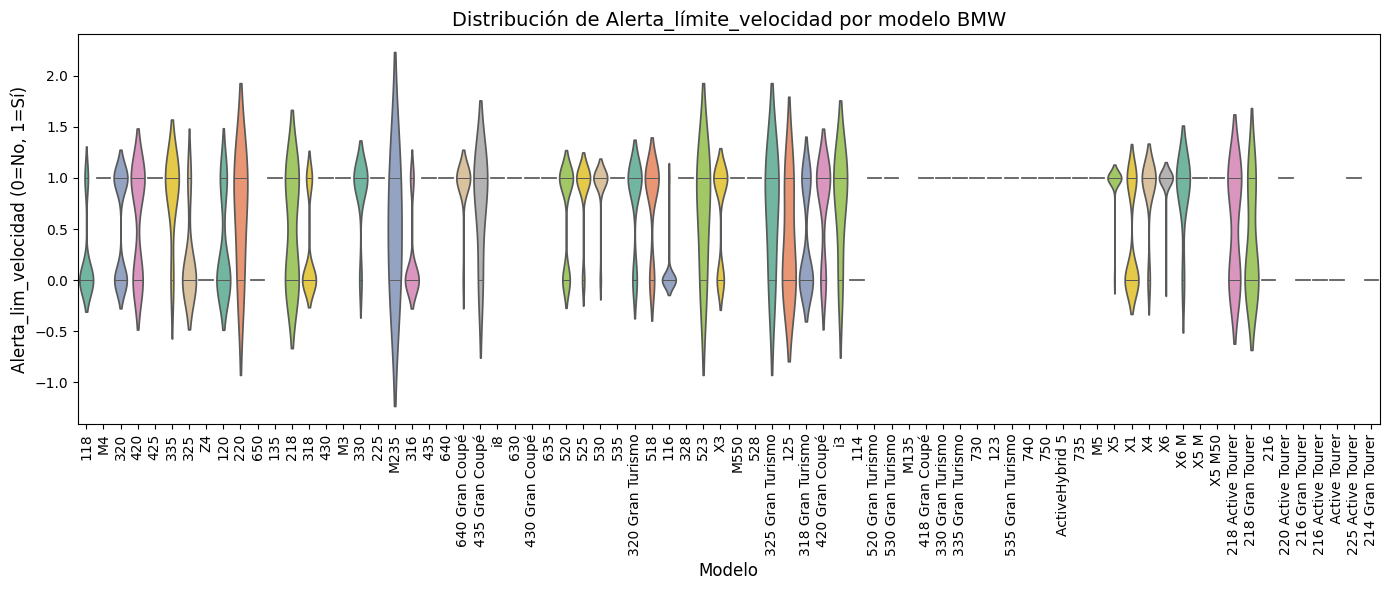

In [ ]:
plt.figure(figsize=(14, 6))
sns.violinplot(x='modelo', y='alerta_lim_velocidad', data=bmw2, inner='stick', palette='Set2')

# Mejorar visualización
plt.title('Distribución de Alerta_límite_velocidad por modelo BMW', fontsize=14)
plt.xlabel('Modelo', fontsize=12)
plt.ylabel('Alerta_lim_velocidad (0=No, 1=Sí)', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Código fácil para transformar alerta_lim_velocidad

# 1. Primero mira qué valores tienes
print("Valores que hay ahora:")
print(bmw2_suave['alerta_lim_velocidad'].unique())

# 2. Transforma todo
bmw2_suave['alerta_lim_velocidad'] = bmw2_suave['alerta_lim_velocidad'].map({
    True: 1,
    False: 0
})

# 3. Cambia los que están vacíos por -1
bmw2_suave['alerta_lim_velocidad'] = bmw2_suave['alerta_lim_velocidad'].fillna(-1)

# 5. Verifica que quedó bien
print("\nDespués del cambio:")
print(bmw2_suave['alerta_lim_velocidad'].value_counts())
print("\n1 = True, 0 = False, -1 = Desconocido")

Valores que hay ahora:
[nan True False]

Después del cambio:
alerta_lim_velocidad
 1.0    2210
 0.0    1838
-1.0     721
Name: count, dtype: int64

1 = True, 0 = False, -1 = Desconocido


<Axes: >

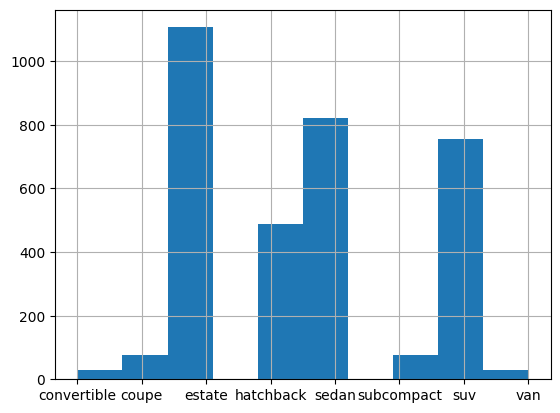

In [ ]:
bmw2["tipo_coche"].hist()

In [ ]:
bmw2_suave.head()

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,DIF_TIEMPO
0,118,140411.0,100.0,diesel,black,Desconocido,True,-1.0,False,True,False,True,-1.0,11300.0,2161 days
1,M4,13929.0,317.0,petrol,grey,convertible,True,-1.0,False,False,True,True,1.0,69700.0,NaT
2,320,183297.0,120.0,diesel,white,Desconocido,False,-1.0,False,True,False,True,0.0,10200.0,2132 days
3,420,128035.0,135.0,diesel,red,convertible,True,-1.0,False,True,True,True,-1.0,25100.0,NaT
4,425,97097.0,160.0,diesel,silver,Desconocido,True,-1.0,False,False,True,True,1.0,33400.0,NaT


In [ ]:
bmw2_suave.groupby (['tipo_coche']).agg ({'precio': 'describe'}).sort_values(by=('precio','mean'))

precio                                                        \
              count          mean           std     min      25%      50%   
tipo_coche                                                                  
subcompact     77.0   9732.467532   3805.413096  1400.0   8200.0   9300.0   
estate       1082.0  13286.321627   5195.634113  1000.0  10400.0  13050.0   
hatchback     486.0  13328.600823   6195.777153  1000.0   9400.0  11900.0   
van            28.0  14646.428571   4216.412565  4800.0  12450.0  14100.0   
Desconocido  1438.0  15758.831711   8127.356265  1100.0  11000.0  14200.0   
sedan         807.0  16264.188352   7987.152761  1000.0  12100.0  14900.0   
convertible    30.0  16796.666667  13681.436790  1800.0   8075.0  12100.0   
suv           746.0  21745.844504  12131.666485  3500.0  14000.0  17900.0   
coupe          75.0  22518.666667  13580.029986  1000.0  11600.0  23100.0   

                                
                 75%       max  
tipo_coche                      
subcompact   11400.0   21700.0  
estate       15800.0   40900.0  
hatchback    16100.0   40500.0  
van          17275.0   22700.0  
Desconocido  18700.0   65400.0  
sedan        19000.0   68700.0  
convertible  23625.0   69700.0  
suv          26700.0  142800.0  
coupe        28300.0   95200.0

In [ ]:
# Le imputamos la el promedio de antigüedad a la variable DIF_TIEMPO, y eliminamos las otras dos variables.
del (bmw2_suave['fecha_registro'])

KeyError: 'fecha_registro'

In [ ]:
del (bmw2_suave['fecha_venta'])

KeyError: 'fecha_venta'

In [ ]:
bmw2_suave['DIF_TIEMPO'].fillna(bmw2_suave['DIF_TIEMPO'].mean(), inplace=True)

/tmp/ipython-input-77704366.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  bmw2_suave['DIF_TIEMPO'].fillna(bmw2_suave['DIF_TIEMPO'].mean(), inplace=True)


In [ ]:
#Después de haber limpiado todos los valores nulls de nuestra tabla, vamos a proceder a hacer el análisis univariable.



# **3. Análisis univariable, explicar alguna información interesante encontrada**


In [ ]:
bmw2_suave.describe()

,km,potencia,aire_acondicionado,alerta_lim_velocidad,precio,DIF_TIEMPO
count,4769.000000,4769.000000,4769.000000,4769.000000,4769.000000,4769
mean,140145.669742,129.236108,0.622143,0.312225,15981.253932,1942 days 07:35:12.846347584
std,58137.705724,39.035262,0.659390,0.719179,8772.447765,595 days 04:41:49.914113720
min,476.000000,25.000000,-1.000000,-1.000000,1000.000000,-2009 days +00:00:00
25%,102321.000000,100.000000,0.000000,0.000000,10900.000000,1767 days 00:00:00
50%,140623.000000,120.000000,1.000000,0.000000,14300.000000,1942 days 07:35:12.846347616
75%,175031.000000,135.000000,1.000000,1.000000,18800.000000,1942 days 07:35:12.846347616
max,484615.000000,423.000000,1.000000,1.000000,142800.000000,10258 days 00:00:00


In [ ]:
bmw2_suave['km'].quantile(np.arange(0, 1.1, 0.1))

,km
0.0,476.0
0.1,64497.2
0.2,92206.8
0.3,110964.2
0.4,125945.8
0.5,140623.0
0.6,154188.8
0.7,167637.2
0.8,182433.4
0.9,203932.4


In [ ]:
bmw2_suave['potencia'].quantile(np.arange(0, 1.1, 0.1))

,potencia
0.0,25.0
0.1,85.0
0.2,100.0
0.3,105.0
0.4,120.0
0.5,120.0
0.6,135.0
0.7,135.0
0.8,150.0
0.9,190.0


In [ ]:
bmw2_suave['precio'].quantile(np.arange(0, 1.1, 0.1))

,precio
0.0,1000.0
0.1,8000.0
0.2,10200.0
0.3,11700.0
0.4,13000.0
0.5,14300.0
0.6,15600.0
0.7,17400.0
0.8,20200.0
0.9,25900.0


In [ ]:
bmw2_suave.DIF_TIEMPO.nsmallest(5)

,DIF_TIEMPO
256,-2009 days
100,-609 days
3935,215 days
140,273 days
3682,424 days


In [ ]:
# Convertir todos los valores negativos a positivos
bmw2_suave['DIF_TIEMPO'] = bmw2_suave['DIF_TIEMPO'].abs()

print("✅ Aplicado: Valor absoluto a DIF_TIEMPO")
print(f"Mínimo después: {bmw2_suave['DIF_TIEMPO'].min()}")

✅ Aplicado: Valor absoluto a DIF_TIEMPO
Mínimo después: 215 days 00:00:00


In [ ]:
# Después de hacer describe, han salido varios valores para las variables numéricas, y podemos ver que el dataset presenta outliers, que son valores muy diferenciados de resto de valores como por ejemplo:
# - El precio para el máximo es casi 12 veces la media, y el minimo es 15.000 veces más bajo.
# - La diferencia de tiempo es 5 veces la media, mientras que el mínimo presenta -2000 días, da un resultado negativo, y eso no puede ser.
# - La potencia minima de 0.00, valor no posible dado que sino el coche no funcionaría. El máximo no tiene un valor exagerado, entendiendo que los coches BMW pueden tener potencias altas.
# - El kilometraje no puede presentar valores negativos. En su minimo los presenta.


 modelo
320                  736
520                  627
318                  557
X3                   433
116                  357
                    ... 
216                    1
220 Active Tourer      1
 Active Tourer         1
225 Active Tourer      1
214 Gran Tourer        1
Name: count, Length: 76, dtype: int64 


 [[<Axes: title={'center': 'km'}>]] 


 [[<Axes: title={'center': 'potencia'}>]] 


 tipo_gasolina
diesel           4572
petrol            181
hybrid_petrol       8
Diesel              5
electro             3
Name: count, dtype: int64 


 color
black          1824
grey           1144
blue            638
white           477
brown           302
silver          283
red              47
beige            37
green            10
orange            6
Desconocido       1
Name: count, dtype: int64 


 tipo_coche
Desconocido    1438
estate         1082
sedan           807
suv             746
hatchback       486
subcompact       77
coupe            75
convertible      30
van      

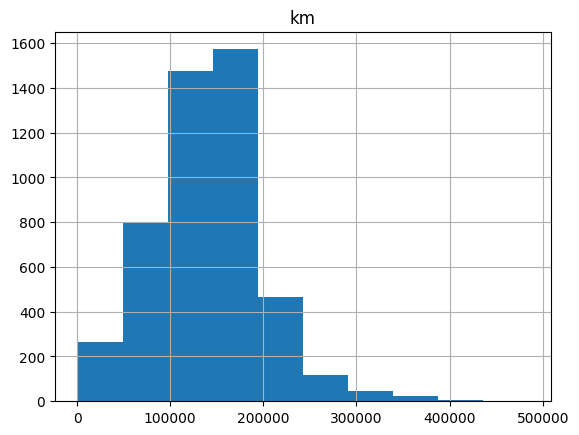

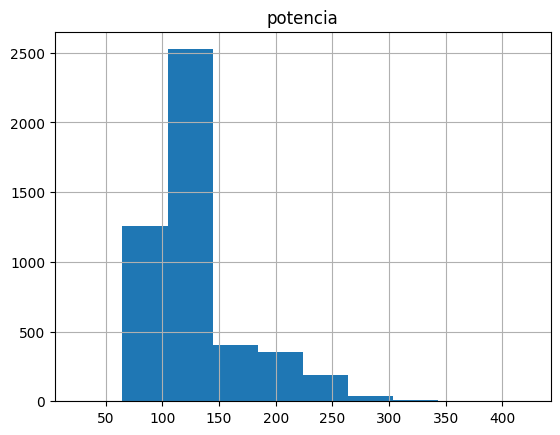

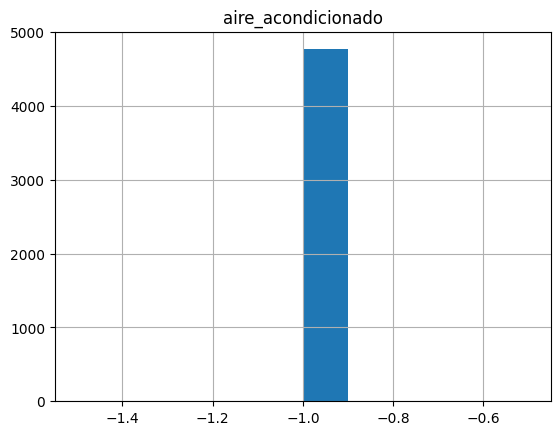

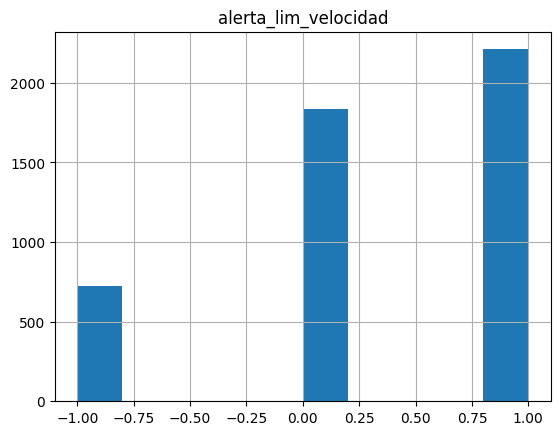

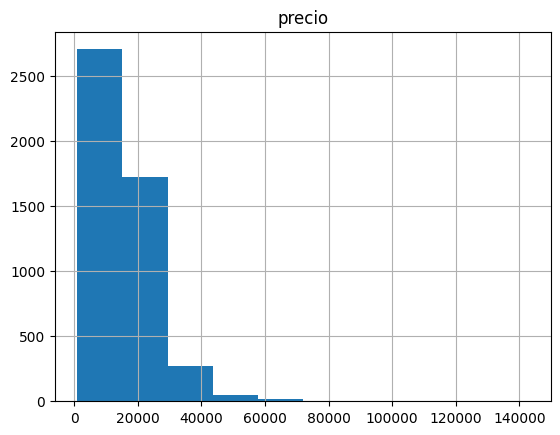

In [ ]:
# Saco los valores por cada columna con value_counts con un bucle
for i in bmw2_suave:
  if bmw2_suave[i].dtype.kind=="O":
    #imprime value_counts de variables categóricas
    print("\n",bmw2_suave[i].value_counts(),"\n")
  elif (bmw2_suave[i].dtype.kind=="f") or (bmw2_suave[i].dtype.kind=="i"):
    #imprime histograma de variables numericas
    print("\n",bmw2_suave.hist(i),"\n")


In [ ]:
# Para las variables categóricas haremos gráficos de barras para ver su distribución.

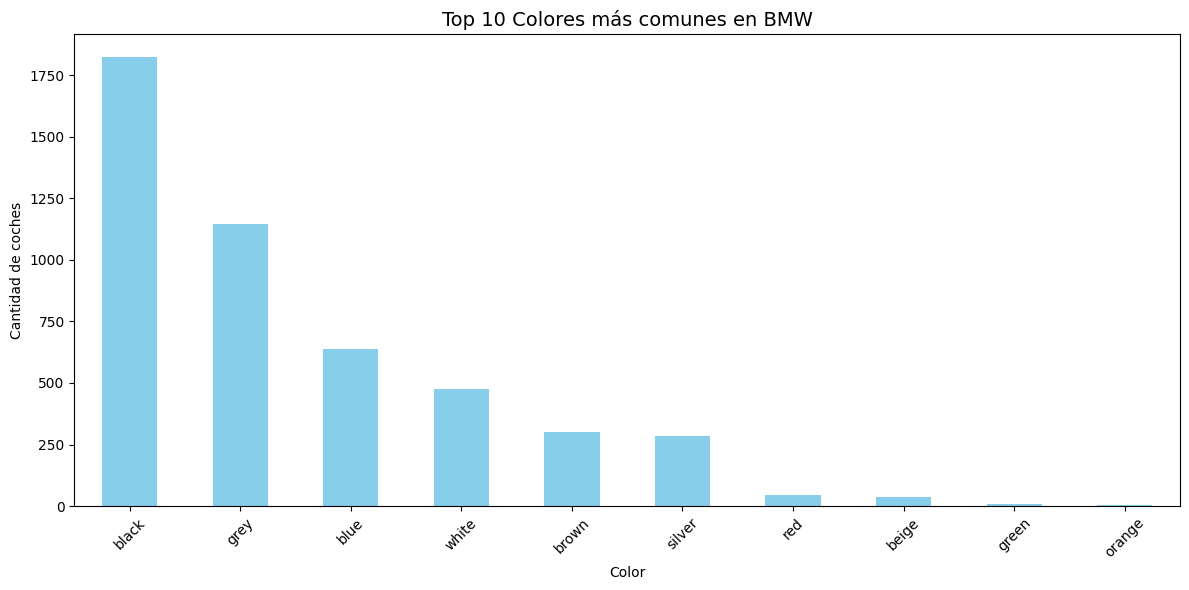

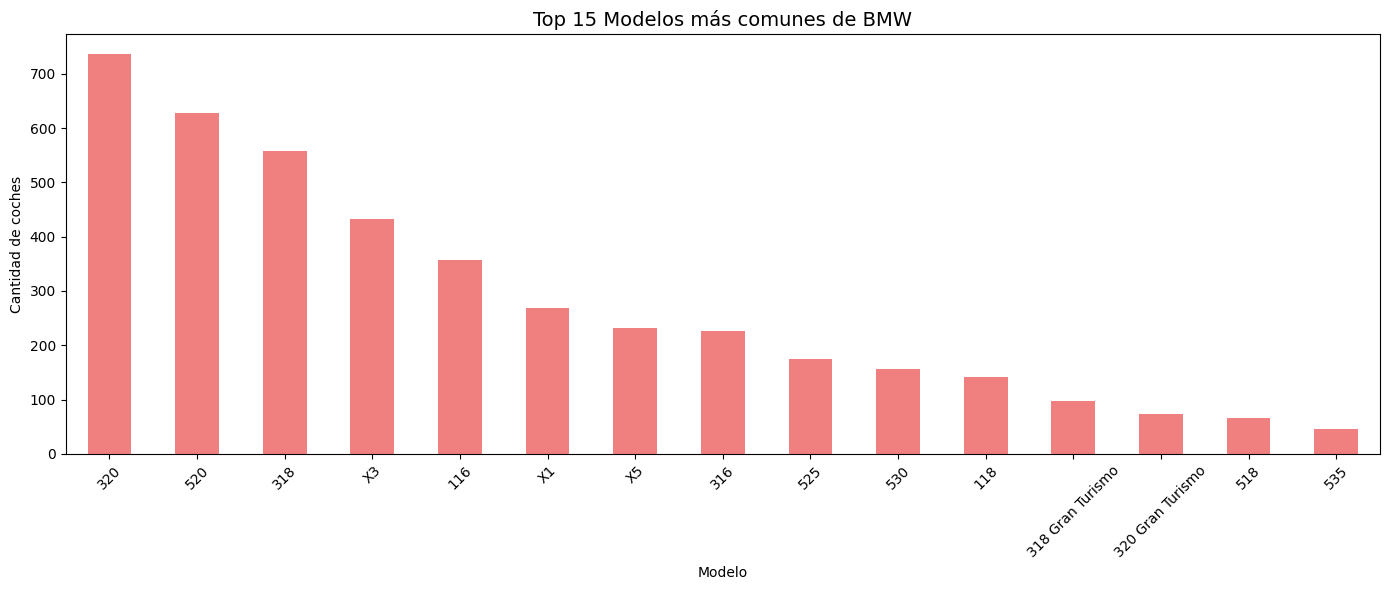

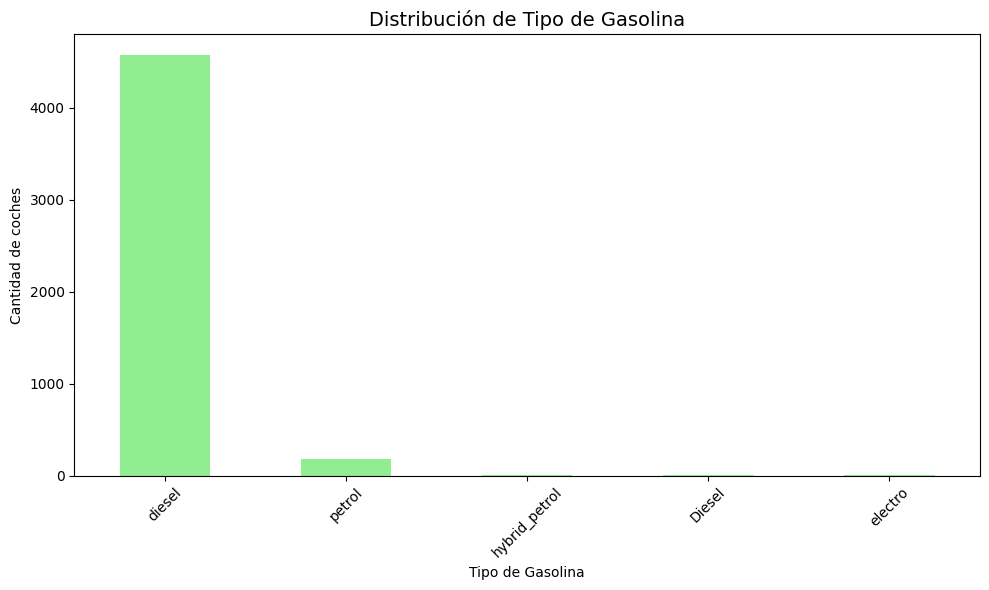

In [ ]:
# Para COLOR
plt.figure(figsize=(12, 6))
bmw2_suave['color'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Colores más comunes en BMW', fontsize=14)
plt.xlabel('Color')
plt.ylabel('Cantidad de coches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Para MODELO
plt.figure(figsize=(14, 6))
bmw2_suave['modelo'].value_counts().head(15).plot(kind='bar', color='lightcoral')
plt.title('Top 15 Modelos más comunes de BMW', fontsize=14)
plt.xlabel('Modelo')
plt.ylabel('Cantidad de coches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Para TIPO_GASOLINA
plt.figure(figsize=(10, 6))
bmw2_suave['tipo_gasolina'].value_counts().plot(kind='bar', color='lightgreen')
plt.title('Distribución de Tipo de Gasolina', fontsize=14)
plt.xlabel('Tipo de Gasolina')
plt.ylabel('Cantidad de coches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **4. Análisis de correlación inicial, ¿Hay alguna variable correlacionada?**

In [ ]:
corr = bmw2_suave.corr(numeric_only = True)
corr

,km,potencia,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio
km,1.000000,-0.039249,0.076836,NaN,0.005935,0.058025,-0.030991,0.161001,-0.009608,-0.418581
potencia,-0.039249,1.000000,0.325228,NaN,0.313199,0.339088,0.227902,0.002156,0.304403,0.665174
volante_regulable,0.076836,0.325228,1.000000,NaN,0.252198,0.271521,0.129877,0.236834,0.132040,0.269029
aire_acondicionado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
camara_trasera,0.005935,0.313199,0.252198,NaN,1.000000,0.195150,0.130925,0.057908,0.118273,0.252529
elevalunas_electrico,0.058025,0.339088,0.271521,NaN,0.195150,1.000000,0.233147,0.196935,0.203750,0.263645
bluetooth,-0.030991,0.227902,0.129877,NaN,0.130925,0.233147,1.000000,0.113992,0.074798,0.205372
gps,0.161001,0.002156,0.236834,NaN,0.057908,0.196935,0.113992,1.000000,-0.059583,-0.015298
alerta_lim_velocidad,-0.009608,0.304403,0.132040,NaN,0.118273,0.203750,0.074798,-0.059583,1.000000,0.279209
precio,-0.418581,0.665174,0.269029,NaN,0.252529,0.263645,0.205372,-0.015298,0.279209,1.000000


In [ ]:
corr.style.background_gradient(cmap='coolwarm')

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/style.py:3807: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
/usr/local/lib/python3.12/dist-packages/pandas/io/formats/style.py:3808: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,km,potencia,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio
km,1.000000,-0.039249,0.076836,nan,0.005935,0.058025,-0.030991,0.161001,-0.009608,-0.418581
potencia,-0.039249,1.000000,0.325228,nan,0.313199,0.339088,0.227902,0.002156,0.304403,0.665174
volante_regulable,0.076836,0.325228,1.000000,nan,0.252198,0.271521,0.129877,0.236834,0.132040,0.269029
aire_acondicionado,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
camara_trasera,0.005935,0.313199,0.252198,nan,1.000000,0.195150,0.130925,0.057908,0.118273,0.252529
elevalunas_electrico,0.058025,0.339088,0.271521,nan,0.195150,1.000000,0.233147,0.196935,0.203750,0.263645
bluetooth,-0.030991,0.227902,0.129877,nan,0.130925,0.233147,1.000000,0.113992,0.074798,0.205372
gps,0.161001,0.002156,0.236834,nan,0.057908,0.196935,0.113992,1.000000,-0.059583,-0.015298
alerta_lim_velocidad,-0.009608,0.304403,0.132040,nan,0.118273,0.203750,0.074798,-0.059583,1.000000,0.279209
precio,-0.418581,0.665174,0.269029,nan,0.252529,0.263645,0.205372,-0.015298,0.279209,1.000000


In [ ]:
# Lo que podemos comprobar en el siguiente mapa de correlación y analizando sobretodo las variables numéricas, lo que podemos comprobar es que los kilometros presentan una correlación negativa con
# respecto al precio, es decir, que cuando el coche aumenta los kilométros recorridos, el precio de éste disminuye. Por otro lado, la potencia tiene una correlación bastante alta con el precio,
# entendiendóse que contra más potencia tiene el coche, más alto será su precio. Tenemos también algunas de las variables booleanas que nos han salido con una correlación con el precio de
# aproximadamente 0,25; lo que, nos da a entender que tienen una pequeña correlación, y que, cuando disponemos de algunos de estos artilugios en el coche, su precio será mayor.

In [ ]:
# A continuación hacemos gráficos scatterplot con las variables más relacionadas que tenemos en el mapa de correlación:
# Por un lado km con precio y por el otro potencia con precio.

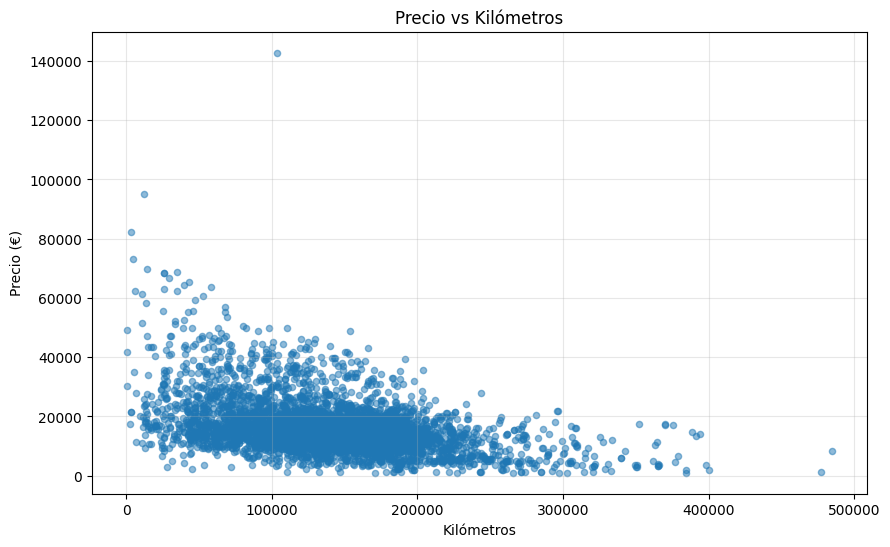

In [ ]:
# Gráfico 1
plt.figure(figsize=(10, 6))
plt.scatter(bmw2_suave['km'], bmw2_suave['precio'], alpha=0.5, s=20)
plt.title('Precio vs Kilómetros')
plt.xlabel('Kilómetros')
plt.ylabel('Precio (€)')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# En este caso, podemos ver una clara correlación negativa, cuando tenemos menos kilómetros hechos es cuando el precio más aumenta.
# Sin embargo, cuando tenemos más kilómetros recorridos, es cuando podemos encontrar un precio más bajo.

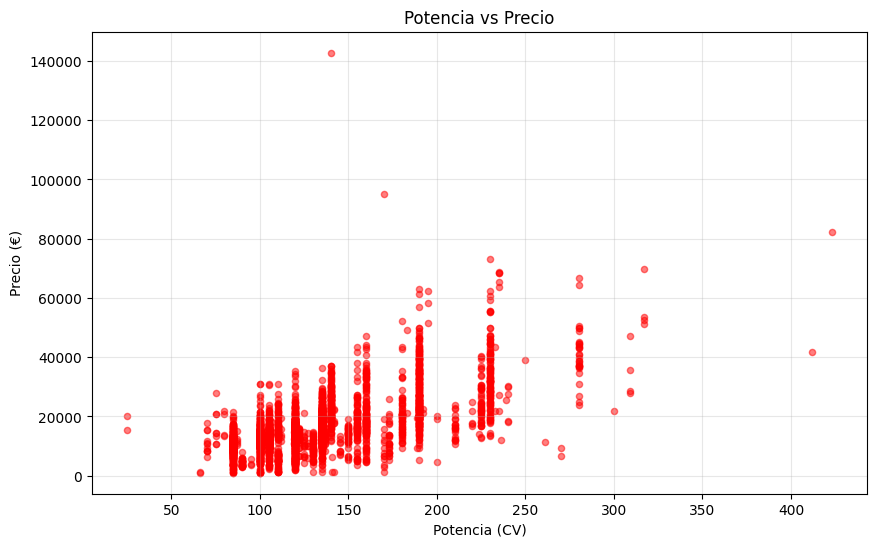

In [ ]:
# Gráfico 2
plt.figure(figsize=(10, 6))
plt.scatter(bmw2_suave['potencia'], bmw2_suave['precio'], alpha=0.5, s=20, color='red')
plt.title('Potencia vs Precio')
plt.xlabel('Potencia (CV)')
plt.ylabel('Precio (€)')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# En este caso, podemos comprobar como al tener de más potencia, tenemos un precio más elevado. Garantizamos que hay presente
# una correlación positiva entre potencia y precio.

In [ ]:
# Las demás variables no son numéricas, sino booleanas, sin embargo, las pasamos a categoricas para hacer el mapa de correlación.

In [ ]:
# Lista de todas las variables booleanas
variables_booleanas = ['volante_regulable', 'camara_trasera', 'elevalunas_electrico',
                       'bluetooth', 'gps', 'alerta_lim_velocidad']

# Análisis para cada variable
for variable in variables_booleanas:
    print(f"\n📊 ANÁLISIS DE {variable.upper()}")
    print("="*40)

    # 1. Filtrar solo True (1) y False (0)
    if variable == 'alerta_lim_velocidad':
        datos_filtrados = bmw2_suave[bmw2_suave[variable].isin([0, 1])]
    else:
        # Para otras booleanas, True=1, False=0
        datos_filtrados = bmw2_suave

    # 2. Contar cuántos hay de cada
    print(f"\nCantidad de coches:")
    print(f"False (0): {(datos_filtrados[variable] == 0).sum()}")
    print(f"True (1): {(datos_filtrados[variable] == 1).sum()}")

    # 3. Porcentajes
    total = len(datos_filtrados)
    print(f"\nPorcentajes:")
    print(f"False: {(datos_filtrados[variable] == 0).sum()/total*100:.1f}%")
    print(f"True: {(datos_filtrados[variable] == 1).sum()/total*100:.1f}%")

    # 4. Ver precio promedio
    print(f"\n💰 Precio promedio:")
    print(f"False: €{datos_filtrados[datos_filtrados[variable] == 0]['precio'].mean():,.0f}")
    print(f"True: €{datos_filtrados[datos_filtrados[variable] == 1]['precio'].mean():,.0f}")

    print("-" * 40)


📊 ANÁLISIS DE VOLANTE_REGULABLE

Cantidad de coches:
False (0): 2117
True (1): 2652

Porcentajes:
False: 44.4%
True: 55.6%

💰 Precio promedio:
False: €13,340
True: €18,090
----------------------------------------

📊 ANÁLISIS DE CAMARA_TRASERA

Cantidad de coches:
False (0): 3802
True (1): 967

Porcentajes:
False: 79.7%
True: 20.3%

💰 Precio promedio:
False: €14,864
True: €20,373
----------------------------------------

📊 ANÁLISIS DE ELEVALUNAS_ELECTRICO

Cantidad de coches:
False (0): 2548
True (1): 2221

Porcentajes:
False: 53.4%
True: 46.6%

💰 Precio promedio:
False: €13,822
True: €18,458
----------------------------------------

📊 ANÁLISIS DE BLUETOOTH

Cantidad de coches:
False (0): 3748
True (1): 1021

Porcentajes:
False: 78.6%
True: 21.4%

💰 Precio promedio:
False: €15,041
True: €19,433
----------------------------------------

📊 ANÁLISIS DE GPS

Cantidad de coches:
False (0): 307
True (1): 4462

Porcentajes:
False: 6.4%
True: 93.6%

💰 Precio promedio:
False: €16,493
True: €15,

In [ ]:
bmw2_suave.loc[bmw2_suave['volante_regulable'].isin([0,1])].groupby(['volante_regulable'])['precio'].describe()

,count,mean,std,min,25%,50%,75%,max
volante_regulable,,,,,,,,
False,2117.0,13340.056684,5621.779616,1000.0,10100.0,12700.0,15700.0,64300.0
True,2652.0,18089.630468,10157.077997,1000.0,12100.0,15800.0,21225.0,142800.0


In [ ]:
bmw2_suave.head()

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,DIF_TIEMPO
0,118,140411.0,100.0,diesel,black,Desconocido,True,1.0,False,True,False,True,-1.0,11300.0,2161 days 00:00:00
1,M4,13929.0,317.0,petrol,grey,convertible,True,1.0,False,False,True,True,1.0,69700.0,1942 days 07:35:12.846347616
2,320,183297.0,120.0,diesel,white,Desconocido,False,0.0,False,True,False,True,0.0,10200.0,2132 days 00:00:00
3,420,128035.0,135.0,diesel,red,convertible,True,1.0,False,True,True,True,-1.0,25100.0,1942 days 07:35:12.846347616
4,425,97097.0,160.0,diesel,silver,Desconocido,True,1.0,False,False,True,True,1.0,33400.0,1942 days 07:35:12.846347616


In [ ]:
bmw2_suave.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4769 entries, 0 to 4842
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype          
---  ------                --------------  -----          
 0   modelo                4769 non-null   object         
 1   km                    4769 non-null   float64        
 2   potencia              4769 non-null   float64        
 3   tipo_gasolina         4769 non-null   object         
 4   color                 4769 non-null   object         
 5   tipo_coche            4769 non-null   object         
 6   volante_regulable     4769 non-null   bool           
 7   aire_acondicionado    4769 non-null   float64        
 8   camara_trasera        4769 non-null   bool           
 9   elevalunas_electrico  4769 non-null   bool           
 10  bluetooth             4769 non-null   bool           
 11  gps                   4769 non-null   bool           
 12  alerta_lim_velocidad  4769 non-null   float64        
 13  precio  

In [ ]:
print("=== DISTRIBUCIÓN DE ALERTA_LIM_VELOCIDAD ===")
distribucion = bmw2_suave['alerta_lim_velocidad'].value_counts().sort_index()
porcentajes = bmw2_suave['alerta_lim_velocidad'].value_counts(normalize=True).sort_index() * 100

print("\nValor | Cantidad | Porcentaje")
print("-" * 35)
for valor in distribucion.index:
    print(f"{valor:5} | {distribucion[valor]:8} | {porcentajes[valor]:.1f}%")

print(f"\nTotal registros: {len(bmw2_suave)}")

=== DISTRIBUCIÓN DE ALERTA_LIM_VELOCIDAD ===

Valor | Cantidad | Porcentaje
-----------------------------------
 -1.0 |      721 | 15.1%
  0.0 |     1838 | 38.5%
  1.0 |     2210 | 46.3%

Total registros: 4769


In [ ]:
bmw2_suave.groupby (['tipo_coche']).agg ({'precio': 'describe'}).sort_values(by=('precio','mean'))

precio                                                        \
              count          mean           std     min      25%      50%   
tipo_coche                                                                  
subcompact     77.0   9732.467532   3805.413096  1400.0   8200.0   9300.0   
estate       1082.0  13286.321627   5195.634113  1000.0  10400.0  13050.0   
hatchback     486.0  13328.600823   6195.777153  1000.0   9400.0  11900.0   
van            28.0  14646.428571   4216.412565  4800.0  12450.0  14100.0   
Desconocido  1438.0  15758.831711   8127.356265  1100.0  11000.0  14200.0   
sedan         807.0  16264.188352   7987.152761  1000.0  12100.0  14900.0   
convertible    30.0  16796.666667  13681.436790  1800.0   8075.0  12100.0   
suv           746.0  21745.844504  12131.666485  3500.0  14000.0  17900.0   
coupe          75.0  22518.666667  13580.029986  1000.0  11600.0  23100.0   

                                
                 75%       max  
tipo_coche                      
subcompact   11400.0   21700.0  
estate       15800.0   40900.0  
hatchback    16100.0   40500.0  
van          17275.0   22700.0  
Desconocido  18700.0   65400.0  
sedan        19000.0   68700.0  
convertible  23625.0   69700.0  
suv          26700.0  142800.0  
coupe        28300.0   95200.0

In [ ]:
bmw2_suave.groupby (['color']).agg ({'precio': 'describe'}).sort_values(by=('precio','mean'))

precio                                                         \
              count          mean           std      min      25%      50%   
color                                                                        
green          10.0   9390.000000   4214.380144   6300.0   7000.0   7900.0   
beige          37.0  14916.216216   4747.544015   7700.0  12100.0  13600.0   
silver        283.0  15287.632509   8542.054230   1000.0  10600.0  14900.0   
blue          638.0  15515.830721   8267.305252   1000.0  10500.0  13400.0   
brown         302.0  15545.695364   7118.318842   3200.0  11200.0  13900.0   
grey         1144.0  15700.524476   9393.261843   1000.0  10900.0  14200.0   
black        1824.0  16125.877193   8678.285415   1100.0  10900.0  14300.0   
red            47.0  16642.553191  12014.515581   2600.0  11200.0  13400.0   
white         477.0  17523.899371   9104.178506   1300.0  12100.0  14900.0   
orange          6.0  18866.666667   6261.203292  13100.0  13775.0  17400.0   
Desconocido     1.0  19200.000000           NaN  19200.0  19200.0  19200.0   

                                
                 75%       max  
color                           
green         9825.0   20500.0  
beige        16700.0   28600.0  
silver       18950.0   73100.0  
blue         17700.0   51200.0  
brown        17700.0   46500.0  
grey         18100.0  142800.0  
black        19200.0   68300.0  
red          17600.0   82400.0  
white        20000.0   66600.0  
orange       22675.0   28300.0  
Desconocido  19200.0   19200.0

In [ ]:
bmw2_suave.groupby (['tipo_gasolina']).agg ({'precio': 'describe'}).sort_values(by=('precio','mean'))

precio                                                         \
                count          mean           std      min      25%      50%   
tipo_gasolina                                                                  
Diesel            5.0  13960.000000   6092.454349   6500.0  11800.0  12700.0   
petrol          181.0  15157.458564  12270.760737   1000.0   6800.0  12400.0   
diesel         4572.0  15975.021872   8506.031519   1000.0  11100.0  14300.0   
electro           3.0  20966.666667    208.166600  20800.0  20850.0  20900.0   
hybrid_petrol     8.0  37575.000000  26731.669287  15500.0  20900.0  25000.0   

                                  
                   75%       max  
tipo_gasolina                     
Diesel         15700.0   23100.0  
petrol         20000.0   82400.0  
diesel         18700.0  142800.0  
electro        21050.0   21200.0  
hybrid_petrol  47775.0   95200.0

In [ ]:
# Habiendo sacado el tipo de gasolina, podemos ver que Diesel (en el que solamente hay 5 registros) y diesel son lo mismo, con lo cual, las agrupamos.

In [ ]:
# Convertir TODO a minúsculas
bmw2_suave['tipo_gasolina'] = bmw2_suave['tipo_gasolina'].str.lower().str.strip()

print("✅ Convertido todo a minúsculas")
print(bmw2_suave['tipo_gasolina'].value_counts())

✅ Convertido todo a minúsculas
tipo_gasolina
diesel           4577
petrol            181
hybrid_petrol       8
electro             3
Name: count, dtype: int64


In [ ]:
bmw2.head(5)

,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
0,118,140411.0,100.0,2012-02-01,diesel,black,NaN,True,True,False,True,NaN,True,NaN,11300.0,2018-01-01
1,M4,13929.0,317.0,NaT,petrol,grey,convertible,True,True,False,False,True,True,True,69700.0,2018-02-01
2,320,183297.0,120.0,2012-04-01,diesel,white,NaN,False,False,False,True,False,True,False,10200.0,2018-02-01
3,420,128035.0,135.0,NaT,diesel,red,convertible,True,True,False,True,True,True,NaN,25100.0,2018-02-01
4,425,97097.0,160.0,NaT,diesel,silver,NaN,True,True,False,False,True,True,True,33400.0,2018-04-01


# **5. Análisis variable vs target, ¿Hay algún insight interesante?**


In [ ]:
print("💰 ¿QUÉ HACE CARO UN BMW?")
print("=" * 30)

# 1. MÁS POTENCIA = MÁS CARO
precio_alta_potencia = bmw2_suave[bmw2_suave['potencia'] > 200]['precio'].mean()
precio_baja_potencia = bmw2_suave[bmw2_suave['potencia'] < 150]['precio'].mean()

print("\n1. POTENCIA:")
print(f"   Alta potencia: €{precio_alta_potencia:,.0f}")
print(f"   Baja potencia: €{precio_baja_potencia:,.0f}")
print(f"   → Más potencia = Más caro")

# 2. MENOS KILÓMETROS = MÁS CARO
precio_pocos_km = bmw2_suave[bmw2_suave['km'] < 50000]['precio'].mean()
precio_muchos_km = bmw2_suave[bmw2_suave['km'] > 150000]['precio'].mean()

print("\n2. KILÓMETROS:")
print(f"   Pocos km: €{precio_pocos_km:,.0f}")
print(f"   Muchos km: €{precio_muchos_km:,.0f}")
print(f"   → Menos km = Más caro")

# 3. TODOS LOS EXTRAS
print("\n3. EXTRAS:")

extras = [
    ('GPS', 'gps'),
    ('Bluetooth', 'bluetooth'),
    ('Volante regulable', 'volante_regulable'),
    ('Cámara trasera', 'camara_trasera'),
    ('Elevalunas eléctrico', 'elevalunas_electrico'),
    ('Alerta límite velocidad', 'alerta_lim_velocidad')
]

for nombre_extra, columna_extra in extras:
    precio_con = bmw2_suave[bmw2_suave[columna_extra] == True]['precio'].mean()
    precio_sin = bmw2_suave[bmw2_suave[columna_extra] == False]['precio'].mean()

    print(f"\n   Con {nombre_extra}: €{precio_con:,.0f}")
    print(f"   Sin {nombre_extra}: €{precio_sin:,.0f}")

    if precio_con > precio_sin:
        print(f"   → Tener {nombre_extra} = Más caro")
    else:
        print(f"   → Tener {nombre_extra} = Más barato")

# RESUMEN
print("\n" + "=" * 30)
print("📌 RESUMEN:")
print("=" * 30)
print("Un BMW es más caro si:")
print("✅ Tiene más potencia")
print("✅ Tiene menos kilómetros")
print("✅ Tiene extras (todos los mencionados)")

💰 ¿QUÉ HACE CARO UN BMW?

1. POTENCIA:
   Alta potencia: €31,892
   Baja potencia: €13,633
   → Más potencia = Más caro

2. KILÓMETROS:
   Pocos km: €25,506
   Muchos km: €13,003
   → Menos km = Más caro

3. EXTRAS:

   Con GPS: €15,946
   Sin GPS: €16,493
   → Tener GPS = Más barato

   Con Bluetooth: €19,433
   Sin Bluetooth: €15,041
   → Tener Bluetooth = Más caro

   Con Volante regulable: €18,090
   Sin Volante regulable: €13,340
   → Tener Volante regulable = Más caro

   Con Cámara trasera: €20,373
   Sin Cámara trasera: €14,864
   → Tener Cámara trasera = Más caro

   Con Elevalunas eléctrico: €18,458
   Sin Elevalunas eléctrico: €13,822
   → Tener Elevalunas eléctrico = Más caro

   Con Alerta límite velocidad: €19,716
   Sin Alerta límite velocidad: €11,569
   → Tener Alerta límite velocidad = Más caro

📌 RESUMEN:
Un BMW es más caro si:
✅ Tiene más potencia
✅ Tiene menos kilómetros
✅ Tiene extras (todos los mencionados)


In [ ]:
# Podemos llegar a la conclusión que un BMW será más caro contra más potencia tenga, contra menos kilometraje tenga, y
# contra más extras tenga, a excepción del GPS.

# **6. Transformación de categóricas a numéricas, ¿Qué variables van a transformar? ¿Que técnica se va usar?**



In [ ]:
# Haremos normalize con las funciones que aparezcan como tipo object y bool en nuestro dataset. Estas serán las que trataremos como categóricas.

In [ ]:
bmw3_suave=bmw2_suave.copy()

In [ ]:
bmw3_suave.info()


<class 'pandas.core.frame.DataFrame'>
Index: 4843 entries, 0 to 4811
Data columns (total 44 columns):
 #   Column                       Non-Null Count  Dtype          
---  ------                       --------------  -----          
 0   modelo                       4769 non-null   object         
 1   km                           4769 non-null   float64        
 2   potencia                     4769 non-null   float64        
 3   tipo_gasolina                4769 non-null   object         
 4   color                        4769 non-null   object         
 5   tipo_coche                   4769 non-null   object         
 6   volante_regulable            4769 non-null   float64        
 7   aire_acondicionado           4769 non-null   float64        
 8   camara_trasera               4769 non-null   float64        
 9   elevalunas_electrico         4769 non-null   float64        
 10  bluetooth                    4769 non-null   float64        
 11  gps                          4769 n

In [ ]:
bmw3_suave.tipo_gasolina.value_counts(normalize=True)

,proportion
tipo_gasolina,
diesel,0.958692
petrol,0.037953
hybrid_petrol,0.001678
Diesel,0.001048
electro,0.000629


In [ ]:
bmw3_suave.color.value_counts(normalize=True)

,proportion
color,
black,0.382470
grey,0.239883
blue,0.133781
white,0.100021
brown,0.063326
silver,0.059342
red,0.009855
beige,0.007758
green,0.002097


In [ ]:
bmw3_suave.tipo_coche.value_counts(normalize=True)

,proportion
tipo_coche,
Desconocido,0.301531
estate,0.226882
sedan,0.169218
suv,0.156427
hatchback,0.101908
subcompact,0.016146
coupe,0.015727
convertible,0.006291
van,0.005871


In [ ]:
bmw3_suave.volante_regulable.value_counts(normalize=True)

,proportion
volante_regulable,
0,1.0


In [ ]:
bmw3_suave.camara_trasera.value_counts(normalize=True)

,proportion
camara_trasera,
False,0.797232
True,0.202768


In [ ]:
bmw3_suave.elevalunas_electrico.value_counts(normalize=True)

,proportion
elevalunas_electrico,
False,0.534284
True,0.465716


In [ ]:
bmw3_suave.bluetooth.value_counts(normalize=True)

,proportion
bluetooth,
False,0.785909
True,0.214091


In [ ]:
bmw3_suave.gps.value_counts(normalize=True)

,proportion
gps,
True,0.935626
False,0.064374


In [ ]:
bmw3_suave.head(5)

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,DIF_TIEMPO
0,118,140411.0,100.0,diesel,black,Desconocido,True,-1.0,False,True,False,True,-1.0,11300.0,2161 days 00:00:00
1,M4,13929.0,317.0,petrol,grey,convertible,True,-1.0,False,False,True,True,1.0,69700.0,1942 days 07:35:12.846347616
2,320,183297.0,120.0,diesel,white,Desconocido,False,-1.0,False,True,False,True,0.0,10200.0,2132 days 00:00:00
3,420,128035.0,135.0,diesel,red,convertible,True,-1.0,False,True,True,True,-1.0,25100.0,1942 days 07:35:12.846347616
4,425,97097.0,160.0,diesel,silver,Desconocido,True,-1.0,False,False,True,True,1.0,33400.0,1942 days 07:35:12.846347616


In [ ]:
# Convertir booleano a entero (True=1, False=0)
bmw3_suave['volante_regulable'] = bmw2_suave['volante_regulable'].astype(int)

# O con np.where
bmw3_suave['volante_regulable'] = np.where(
    bmw2_suave['volante_regulable'] == True,  # Sin comillas
    1,
    0
)

In [ ]:
# Convertir booleano a entero (True=1, False=0)
bmw3_suave['camara_trasera'] = bmw2_suave['camara_trasera'].astype(int)

# O con np.where
bmw3_suave['camara_trasera'] = np.where(
    bmw2_suave['camara_trasera'] == True,  # Sin comillas
    1,
    0
)

In [ ]:
# Convertir booleano a entero (True=1, False=0)
bmw3_suave['elevalunas_electrico'] = bmw3_suave['elevalunas_electrico'].astype(int)

# O con np.where
bmw3_suave['elevalunas_electrico'] = np.where(
    bmw3_suave['elevalunas_electrico'] == True,  # Sin comillas
    1,
    0
)

In [ ]:
# Convertir booleano a entero (True=1, False=0)
bmw3_suave['bluetooth'] = bmw3_suave['bluetooth'].astype(int)

# O con np.where
bmw3_suave['bluetooth'] = np.where(
    bmw3_suave['bluetooth'] == True,  # Sin comillas
    1,
    0
)

In [ ]:
# Convertir booleano a entero (True=1, False=0)
bmw3_suave['gps'] = bmw3_suave['gps'].astype(int)

# O con np.where
bmw3_suave['gps'] = np.where(
    bmw3_suave['gps'] == True,  # Sin comillas
    1,
    0
)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
color_encoded = ohe.fit_transform(bmw3_suave[['color']])
color_df = pd.DataFrame(color_encoded, columns=ohe.get_feature_names_out(['color']))
bmw3_suave = pd.concat([bmw3_suave, color_df], axis=1)

In [ ]:
bmw3_suave

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,...,color_beige,color_black,color_blue,color_brown,color_green,color_grey,color_orange,color_red,color_silver,color_white
0,118,140411.0,100.0,diesel,black,Desconocido,1.0,-1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,M4,13929.0,317.0,petrol,grey,convertible,1.0,-1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,320,183297.0,120.0,diesel,white,Desconocido,0.0,-1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,420,128035.0,135.0,diesel,red,convertible,1.0,-1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,425,97097.0,160.0,diesel,silver,Desconocido,1.0,-1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3817,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3880,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4356,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
tipo_coche_encoded = ohe.fit_transform(bmw3_suave[['tipo_coche']])
tipo_coche_df = pd.DataFrame(tipo_coche_encoded, columns=ohe.get_feature_names_out(['tipo_coche']))
bmw3_suave = pd.concat([bmw3_suave, tipo_coche_df], axis=1)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
tipo_gasolina_encoded = ohe.fit_transform(bmw3_suave[['tipo_gasolina']])
tipo_gasolina_df = pd.DataFrame(tipo_gasolina_encoded, columns=ohe.get_feature_names_out(['tipo_gasolina']))
bmw3_suave = pd.concat([bmw3_suave, tipo_gasolina_df], axis=1)

# **7. Escalar variables (usando minmaxscaler) y luego aplicar la correlación final de variables ¿Hay alguna variable finalmente correlacionada?**


In [ ]:
# Escalamos solo variables numéricas y que no sea el target.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
bmw3_suave['Potencia_escalada'] = scaler.fit_transform(bmw3_suave[['potencia']])

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
bmw3_suave['Kilometros_escalados'] = scaler.fit_transform(bmw3_suave[['km']])

In [ ]:
bmw3_suave

,modelo,km,potencia,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,...,tipo_coche_van,tipo_coche_nan,tipo_gasolina_Diesel,tipo_gasolina_diesel,tipo_gasolina_electro,tipo_gasolina_hybrid_petrol,tipo_gasolina_petrol,tipo_gasolina_nan,Potencia_escalada,Kilometros_escalados
0,118,140411.0,100.0,diesel,black,Desconocido,1.0,-1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.188442,0.289039
1,M4,13929.0,317.0,petrol,grey,convertible,1.0,-1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.733668,0.027787
2,320,183297.0,120.0,diesel,white,Desconocido,0.0,-1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.238693,0.377621
3,420,128035.0,135.0,diesel,red,convertible,1.0,-1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.276382,0.263476
4,425,97097.0,160.0,diesel,silver,Desconocido,1.0,-1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.339196,0.199573
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4356,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN
4753,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN
4802,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN
4806,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN


In [ ]:
bmw3_suave.isnull().sum()

,0
modelo,74
km,74
potencia,74
tipo_gasolina,74
color,74
tipo_coche,74
volante_regulable,74
aire_acondicionado,74
camara_trasera,74
elevalunas_electrico,74


In [ ]:
corr2 = bmw3_suave.corr(numeric_only=True)  # ✅
plt.figure(figsize=(1, 1))
corr2.style.background_gradient(cmap='coolwarm')

,km,potencia,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,color_Desconocido,color_beige,color_black,color_blue,color_brown,color_green,color_grey,color_orange,color_red,color_silver,color_white,tipo_coche_Desconocido,tipo_coche_convertible,tipo_coche_coupe,tipo_coche_estate,tipo_coche_hatchback,tipo_coche_sedan,tipo_coche_subcompact,tipo_coche_suv,tipo_coche_van,tipo_coche_nan,tipo_gasolina_Diesel,tipo_gasolina_diesel,tipo_gasolina_electro,tipo_gasolina_hybrid_petrol,tipo_gasolina_petrol,tipo_gasolina_nan,Potencia_escalada,Kilometros_escalados
km,1.000000,-0.039249,0.076836,nan,0.005935,0.058025,-0.030991,0.161001,-0.009608,-0.418581,0.001828,-0.010311,0.007751,-0.006604,0.015890,0.013519,0.008492,0.014866,-0.022424,0.006450,-0.028530,0.016761,-0.033848,-0.068526,0.141993,-0.065986,0.022901,-0.000401,-0.093281,-0.036305,-0.062546,0.024520,0.073213,0.008899,-0.026752,-0.045138,-0.066370,-0.039249,1.000000
potencia,-0.039249,1.000000,0.325228,nan,0.313199,0.339088,0.227902,0.002156,0.304403,0.665174,0.004020,-0.007624,0.000529,-0.016522,0.021345,0.035106,0.004968,-0.006195,-0.007570,-0.007420,-0.000792,0.011728,0.020718,0.098341,-0.034416,-0.186125,0.010697,-0.057281,0.144160,0.034274,-0.003905,0.007990,-0.034136,-0.016650,-0.012982,0.047514,-0.004159,1.000000,-0.039249
volante_regulable,0.076836,0.325228,1.000000,nan,0.252198,0.271521,0.129877,0.236834,0.132040,0.269029,-0.016356,-0.017464,0.020890,-0.006334,0.009131,0.013311,0.001340,0.007907,-0.013654,-0.008538,-0.021783,-0.004719,0.044422,0.031551,0.009438,-0.116927,0.026011,-0.021096,0.052918,0.018961,-0.013565,0.011308,0.005371,-0.011249,-0.004628,0.002001,-0.012136,0.325228,0.076836
aire_acondicionado,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
camara_trasera,0.005935,0.313199,0.252198,nan,1.000000,0.195150,0.130925,0.057908,0.118273,0.252529,-0.007346,0.003106,0.003287,-0.002159,-0.017133,0.011244,0.003350,-0.003165,-0.023985,0.009441,0.004865,0.006298,-0.033558,0.020051,-0.019416,-0.050134,-0.024214,-0.010079,0.074041,0.029485,0.014092,0.021419,-0.016053,-0.012653,-0.020673,0.015056,0.011212,0.313199,0.005935
elevalunas_electrico,0.058025,0.339088,0.271521,nan,0.195150,1.000000,0.233147,0.196935,0.203750,0.263645,0.015541,-0.016091,0.030451,-0.021115,0.035682,0.002916,0.005058,-0.009686,0.008489,-0.027763,-0.037867,-0.007101,0.000138,0.081334,0.046219,-0.065482,0.009804,-0.055070,0.002758,0.016278,-0.044953,0.016512,0.025425,-0.006658,-0.017727,0.000377,-0.045353,0.339088,0.058025
bluetooth,-0.030991,0.227902,0.129877,nan,0.130925,0.233147,1.000000,0.113992,0.074798,0.205372,0.027935,-0.005462,-0.009414,0.009215,-0.003088,0.009640,0.000003,-0.018678,0.010037,0.015088,-0.006834,-0.003905,0.048970,0.106563,-0.020233,0.011064,-0.003168,-0.017478,-0.022506,0.020086,-0.002447,0.020195,-0.017936,0.007293,-0.021395,0.025385,-0.005067,0.227902,-0.030991
gps,0.161001,0.002156,0.236834,nan,0.057908,0.196935,0.113992,1.000000,-0.059583,-0.015298,0.003790,-0.016435,-0.005770,0.014195,0.024165,0.011998,0.021236,0.009290,0.008536,-0.020650,-0.041425,0.005528,-0.000730,-0.014895,0.039266,0.014479,0.018822,0.033402,-0.075919,-0.002196,-0.040502,0.007600,0.018156,0.006581,-0.010126,0.002633,-0.038306,0.002156,0.161001
alerta_lim_velocidad,-0.009608,0.304403,0.132040,nan,0.118273,0.203750,0.074798,-0.059583,1.000000,0.279209,0.013972,0.011669,0.003559,-0.020473,0.021782,0.012122,0.004612,0.001100,-0.025648,-0.011187,0.004361,-0.016135,-0.001305,0.017854,0.024887,-0.095325,0.002446,-0.024913,0.061685,0.035391,0.006884,0.017638,0.005148,0.000736,-0.024924,-0.011017,0.011635,0.304403,-0.009608
precio,-0.418581,0.665174,0.269029,nan,0.252529,0.263645,0.205372,-0.015298,0.279209,1.000000,0.017900,-0.015938,0.015796,-0.009729,0.013482,0.006951,-0.020685,-0.014561,-0.002028,-0.008113,0.015463,-0.003833,0.007411,0.09

<Figure size 100x100 with 0 Axes>